In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT,DATASETS_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout


import torchvision as tv

from scripts.model_serialization import load_model

no_grad_guard = torch.no_grad()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
###############################################
# This configures which model/dataset we are evaluating
# Identity
# model_path = PROJECT_ROOT / "models/identity/vit/good_freeze_embeddings3/config.ptc"
model_path = Path(
    # "/home/dherrera/git/zoo_vision/models/identity/vit/good_freeze_embeddings4/config.ptc"
    "/home/dherrera/git/zoo_vision/models/identity/vit/all/checkpoint-13855/config.json"
)
datasets = {
    name: fo.load_dataset(name)
    for name in [
        "zoo-elephants-identity-train",
        "zoo-elephants-identity-val",
        "zoo-elephants-identity-id3",
        "zoo-elephants-identity-tracks",
    ]
}

# Behaviour
# model_path = PROJECT_ROOT / "models/sleep/vit/mix/config.ptc"
# ds_zoo_elephants = fo.load_dataset("zoo-elephants-sleep-mix")

###############################################

ds0 = next(datasets.values().__iter__())
classes = sorted(ds0.classes["ground_truth"])
print(classes)

['01_Chandra', '02_Indi', '03_Fahra', '04_Panang', '05_Thai']


In [6]:
# model_path = PROJECT_ROOT / "models/identity/freeze09/dense121_c5_identity2.pth"
model = load_model(model_path).to(torch.device("cuda"))
model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [7]:
import PIL

import transformers

image_processor = transformers.AutoImageProcessor.from_pretrained(model_path.parent)
print(f"{image_processor.image_mean=}, {image_processor.image_std=}")


def transform_and_preprocess(image: PIL.Image):
    image = np.asarray(image)
    # image = tv.transforms.Resize([224,224])(image)
    image = image_processor.preprocess(image)["pixel_values"][0]
    image = torch.from_numpy(image)
    # image = image.permute([2,0,1])
    # raise RuntimeError(f"{type(image)}")
    # raise RuntimeError(f"type is {type(image)}, {str(image.shape)=}")
    return image


sample0 = next(ds0.iter_samples())
# sample0 = {
#     "filepath": "/media/dherrera/ElephantExternal/elephants/tracks/new/zag_elp_cam_019/000001/zag_elp_cam_019_20250125_220949_t1_221.png"
# }
im0 = PIL.Image.open(sample0["filepath"])
print(f"{transform_and_preprocess(im0).shape=}")
t0 = transform_and_preprocess(im0).unsqueeze(0).to(torch.device("cuda"))
r0 = model(t0)
print(f"{r0=}")
print(r0["logits"].shape)

image_processor.image_mean=[0.48500001430511475, 0.4560000002384186, 0.4059999883174896], image_processor.image_std=[0.2290000021457672, 0.2239999920129776, 0.22499999403953552]
transform_and_preprocess(im0).shape=torch.Size([3, 224, 224])
r0=ImageClassifierOutput(loss=None, logits=tensor([[ 1.8436, -0.7541, -0.7690, -0.7544, -0.8771]], device='cuda:0',
       grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
torch.Size([1, 5])


In [8]:
config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes, store_logits=True
        ),
        "classes": classes,
        "transforms": transform_and_preprocess,
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

print("Applying model to samples...")
# ds_zoo_elephants.apply_model(fo_model, label_field="zoo_identity")
# predictions_view = ds_zoo_elephants.take(100, seed=51)
datasets.pop("all", "no_fail")
for name, ds_i in datasets.items():
    print(f"{name}...")
    ds_i.apply_model(fo_model, label_field="prediction")

# Merge datasets
if fo.dataset_exists("temp"):
    fo.delete_dataset("temp")
ds_all = fo.Dataset("temp")
for ds_i in datasets.values():
    ds_all.merge_samples(ds_i)
datasets["all"] = ds_all

# high_conf_view = predictions_view.filter_labels("zoo maskrcnn", fo.ViewField("confidence") > 0.85, only_matches=False)
# session.view = predictions_view

Applying model to samples...
zoo-elephants-identity-train...
 100% |███████████████| 9283/9283 [1.6m elapsed, 0s remaining, 92.7 samples/s]      
zoo-elephants-identity-val...
 100% |█████████████████| 187/187 [2.3s elapsed, 0s remaining, 94.8 samples/s]      
zoo-elephants-identity-id3...
 100% |█████████████████| 953/953 [10.3s elapsed, 0s remaining, 93.6 samples/s]      
zoo-elephants-identity-tracks...
 100% |███████████████| 4626/4626 [48.4s elapsed, 0s remaining, 93.4 samples/s]      


Dataset zoo-elephants-identity-train
{'01_Chandra': 1465, '02_Indi': 1592, '03_Fahra': 1506, '04_Panang': 1321, '05_Thai': 3399}
{'01_Chandra': 1465, '02_Indi': 1592, '03_Fahra': 1502, '04_Panang': 1323, '05_Thai': 3401}
              precision    recall  f1-score   support

  01_Chandra       1.00      1.00      1.00      1465
     02_Indi       1.00      1.00      1.00      1592
    03_Fahra       1.00      1.00      1.00      1506
   04_Panang       0.99      1.00      1.00      1321
     05_Thai       1.00      1.00      1.00      3399

    accuracy                           1.00      9283
   macro avg       1.00      1.00      1.00      9283
weighted avg       1.00      1.00      1.00      9283



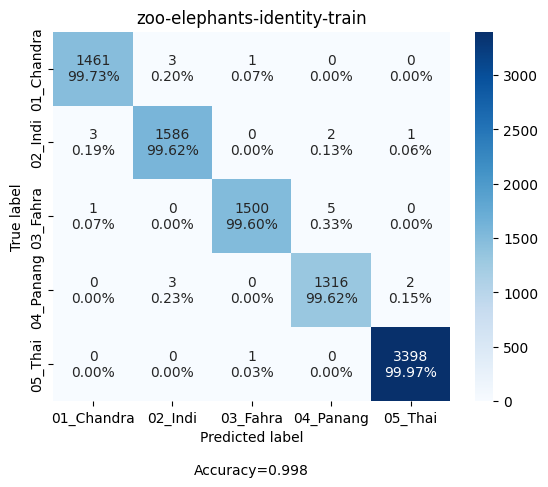

Dataset zoo-elephants-identity-val
{'01_Chandra': 22, '02_Indi': 25, '03_Fahra': 46, '04_Panang': 46, '05_Thai': 48}
{'01_Chandra': 22, '02_Indi': 42, '03_Fahra': 34, '04_Panang': 36, '05_Thai': 53}
              precision    recall  f1-score   support

  01_Chandra       0.82      0.82      0.82        22
     02_Indi       0.52      0.88      0.66        25
    03_Fahra       0.91      0.67      0.78        46
   04_Panang       0.94      0.74      0.83        46
     05_Thai       0.91      1.00      0.95        48

    accuracy                           0.82       187
   macro avg       0.82      0.82      0.81       187
weighted avg       0.86      0.82      0.82       187



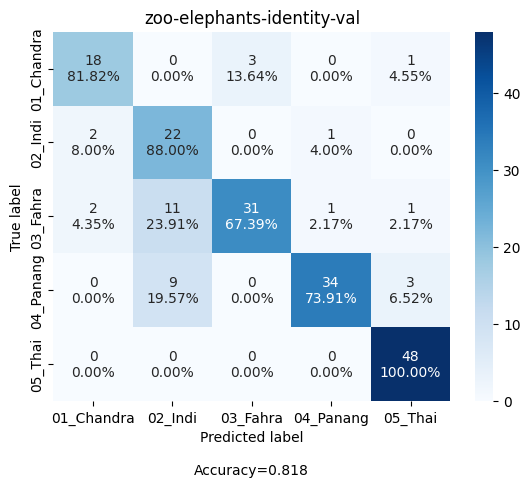

Dataset zoo-elephants-identity-id3
{'01_Chandra': 184, '02_Indi': 178, '03_Fahra': 198, '04_Panang': 197, '05_Thai': 196}
{'01_Chandra': 202, '02_Indi': 174, '03_Fahra': 179, '04_Panang': 190, '05_Thai': 208}
              precision    recall  f1-score   support

  01_Chandra       0.89      0.98      0.93       184
     02_Indi       0.95      0.93      0.94       178
    03_Fahra       0.97      0.87      0.92       198
   04_Panang       0.98      0.94      0.96       197
     05_Thai       0.94      1.00      0.97       196

    accuracy                           0.95       953
   macro avg       0.95      0.95      0.95       953
weighted avg       0.95      0.95      0.95       953



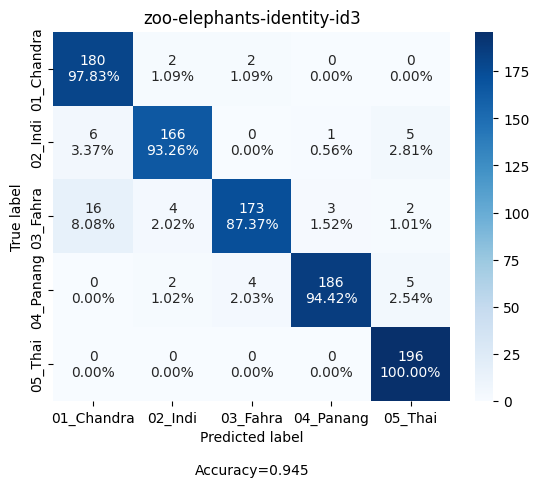

Dataset zoo-elephants-identity-tracks
{'01_Chandra': 1859, '02_Indi': 2023, '05_Thai': 744}
{'01_Chandra': 1296, '02_Indi': 1415, '03_Fahra': 509, '04_Panang': 163, '05_Thai': 1243}
              precision    recall  f1-score   support

  01_Chandra       0.88      0.61      0.72      1859
     02_Indi       0.93      0.65      0.77      2023
    03_Fahra       0.00      0.00      0.00         0
   04_Panang       0.00      0.00      0.00         0
     05_Thai       0.56      0.94      0.70       744

    accuracy                           0.68      4626
   macro avg       0.47      0.44      0.44      4626
weighted avg       0.85      0.68      0.74      4626



/home/dherrera/git/zoo_vision/scripts/cf_matrix.py:71: RuntimeWarning: invalid value encountered in divide
  ["{0:.2%}".format(value) for value in cf[r, :] / row_sum]


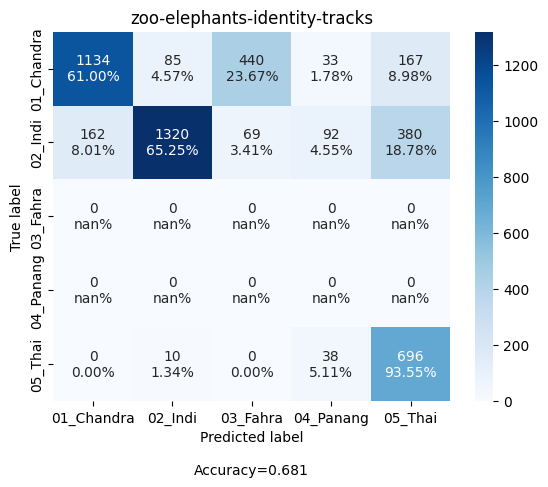

Dataset all
{'01_Chandra': 3530, '02_Indi': 3818, '03_Fahra': 1750, '04_Panang': 1564, '05_Thai': 4387}
{'01_Chandra': 2985, '02_Indi': 3223, '03_Fahra': 2224, '04_Panang': 1712, '05_Thai': 4905}
              precision    recall  f1-score   support

  01_Chandra       0.94      0.79      0.86      3530
     02_Indi       0.96      0.81      0.88      3818
    03_Fahra       0.77      0.97      0.86      1750
   04_Panang       0.90      0.98      0.94      1564
     05_Thai       0.88      0.99      0.93      4387

    accuracy                           0.89     15049
   macro avg       0.89      0.91      0.89     15049
weighted avg       0.90      0.89      0.89     15049



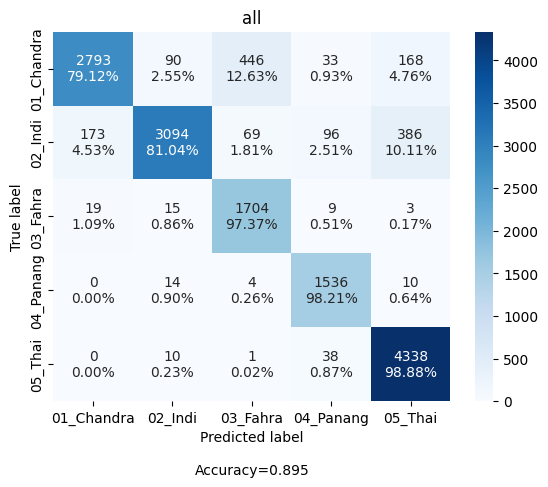

In [9]:
import seaborn as sns
from scripts.cf_matrix import make_confusion_matrix

for ds_i in datasets.values():
    ds_i.delete_evaluations()

for name, ds_i in datasets.items():
    print(f"Dataset {name}")
    ds_i.delete_evaluations()
    results = ds_i.evaluate_classifications(
        pred_field="prediction",
        gt_field="ground_truth",
        eval_key="eval",
        method="simple",
        classes=classes,
    )
    gt_counts = dict(sorted(ds_i.count_values("ground_truth.label").items()))
    pd_counts = dict(sorted(ds_i.count_values("prediction.label").items()))
    print(gt_counts)
    print(pd_counts)
    results.print_report()

    m = results.confusion_matrix()
    # sns.heatmap(m, annot=True,xticklabels=classes, yticklabels=classes, fmt="d")
    make_confusion_matrix(m, categories=classes)
    plt.gca().set_title(name)
    plt.show()

In [10]:
from fiftyone import ViewField as F

ds = datasets["zoo-elephants-identity-id3"]
session = fo.launch_app(ds, auto=False)

session.view = (
    ds
    # .match_tags("validation")
    .match(F("prediction.label") != F("ground_truth.label"))
    # .sort_by("uniqueness", reverse=True)
)
session.open_tab()

Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port
Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>